In [1]:
import pandas as pd
import numpy as np
import os
import numpy as np
import os
import pandas as pd
new_path = r'd:\Desktop\PHD\reasearch\biyework\maml'
# current_path = os.getcwd()
# print(current_path)
# # 检查当前路径是否切换成功
if os.getcwd() != new_path:
    os.chdir(new_path)
current_path = os.getcwd()
print(current_path)

# 返回一个向量 (x_direction, y_direction, distance)，表示节点和网关之间的方向
def calculate_location_vector(node_coord, gateway_coord):
    # 方向从节点指向网关，用于描述节点与网关之间的相对方位
    direction_vector = np.array(gateway_coord) - np.array(node_coord)
    norm = np.linalg.norm(direction_vector)
    if norm == 0:
        direction_vector = np.zeros_like(direction_vector)
    else:
        direction_vector = direction_vector / norm
    location_vector = [direction_vector[0], direction_vector[1], norm]
    return location_vector


d:\Desktop\PHD\reasearch\biyework\maml


下面这个部分是用来生成location_vector的，轻易别跑

In [ ]:
from model.v1.RGM.src.parameter_paser import parse_args_location
args = parse_args_location()
print(f"\nUsing configuration file: {args.configs}\n")

output_dir = r"model\v1\output"
os.makedirs(output_dir, exist_ok=True)

location_vector_path = os.path.join(output_dir, args.location_vector_name)
# 网关坐标
gateway_coord_m = (args.gateway_X, args.gateway_Y)
with open(location_vector_path, "w") as in_file:
    # 写入 CSV 文件头
    in_file.write("location_id,x,y,distance,distance_true,idx\n")
    # 遍历 label_coordinate.csv 文件，计算节点和网关之间的方向向量
    df = pd.read_csv(r"model\v1\input\label_coordinate_v2.csv") 
    idx = 0
    for index, row in df.iterrows():
        node_id = row['id']
        node_coord = (row['x'], row['y'])
        if node_coord != gateway_coord_m:  # 排除网关坐标
            location_vector = calculate_location_vector(node_coord, gateway_coord_m)
            in_file.write(f"{node_id},{location_vector[0]},{location_vector[1]},{location_vector[2]},{location_vector[2]},{idx}\n")
            idx += 1
# 确保文件已经写入成功后再读取
df = pd.read_csv(location_vector_path)
# 将distance_true列进行缩放，将像素距离转化成真实距离
df['distance_true'] = df['distance_true'] * args.distance_scale
# 将 distance 列归一化
df['distance'] = (df['distance'] - df['distance'].mean()) / df['distance'].std()
df.to_csv(location_vector_path, index=False)



Using configuration file: location_vector.yml



d:\mysoft2\miniconda3\envs\MAML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. 路径损耗模型：  
   $$ PL(d) = PL_0 + 10\gamma_{SF} \log_{10} d $$  

2. 功率平衡方程：  
   $$ PL(d) = P_{TX} - \text{RSSI} $$

3. 联立可以得到：
 $$ \text{RSSI} = P_{TX} - PL_0 - 10\gamma_{SF} \log_{10} d $$  

SF: 10.0, γ_SF: 3.8961, PL_0: 38.3693
SF: 11.0, γ_SF: 4.1226, PL_0: 34.5041
SF: 12.0, γ_SF: 3.0591, PL_0: 50.0947
SF: 7.0, γ_SF: 2.0337, PL_0: 61.1502
SF: 8.0, γ_SF: 3.3014, PL_0: 45.6158
SF: 9.0, γ_SF: 5.2451, PL_0: 25.4786
拟合结果已保存至 model\v1\output\sf_parameters.csv


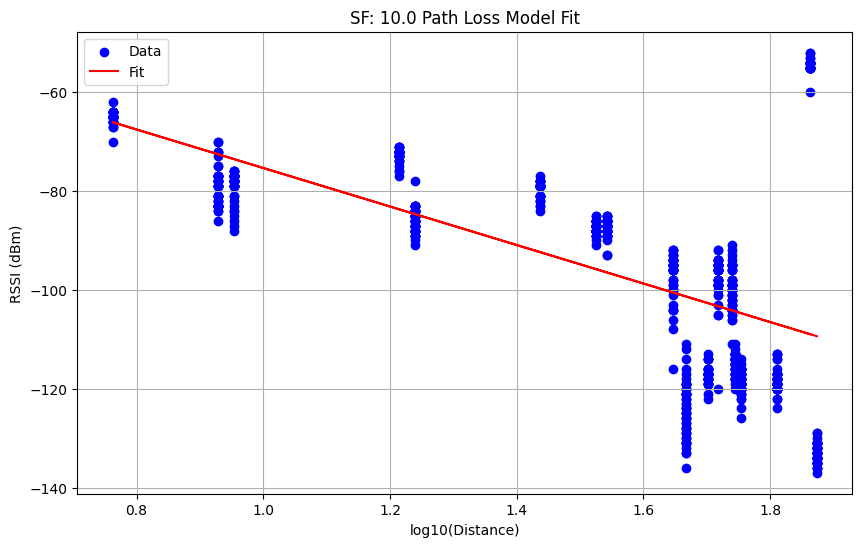

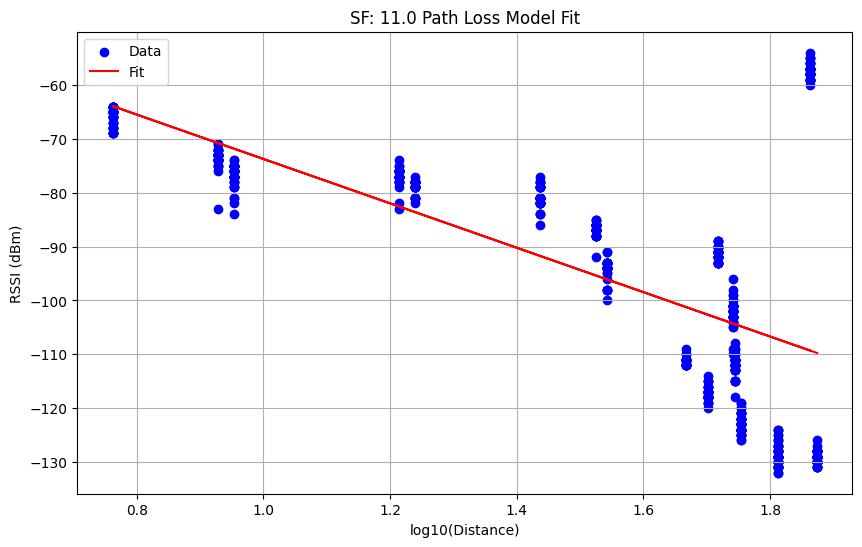

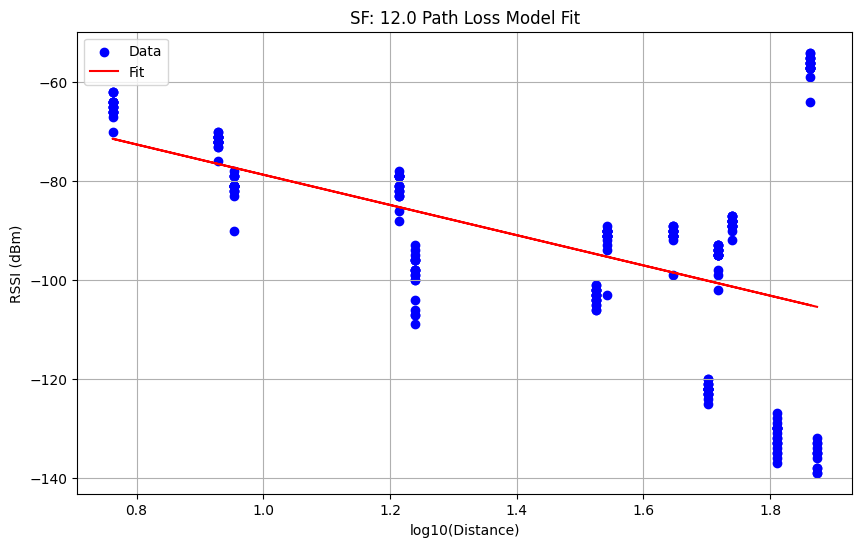

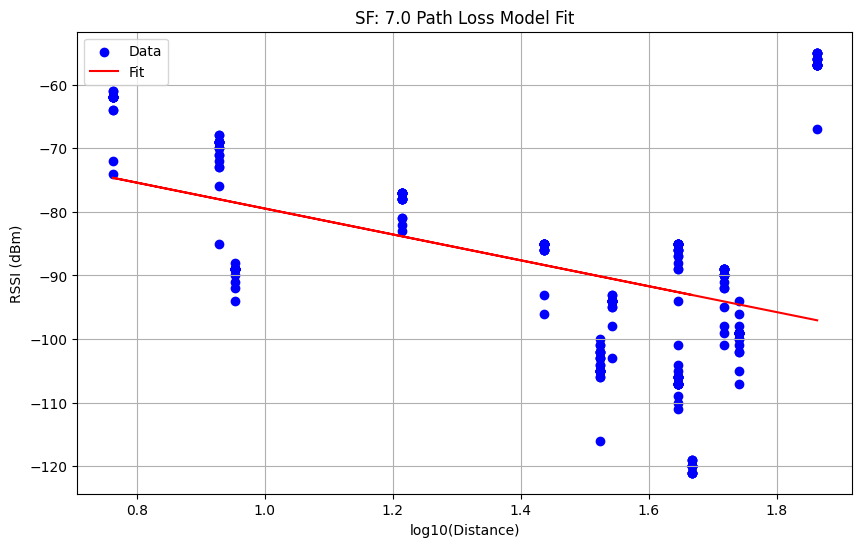

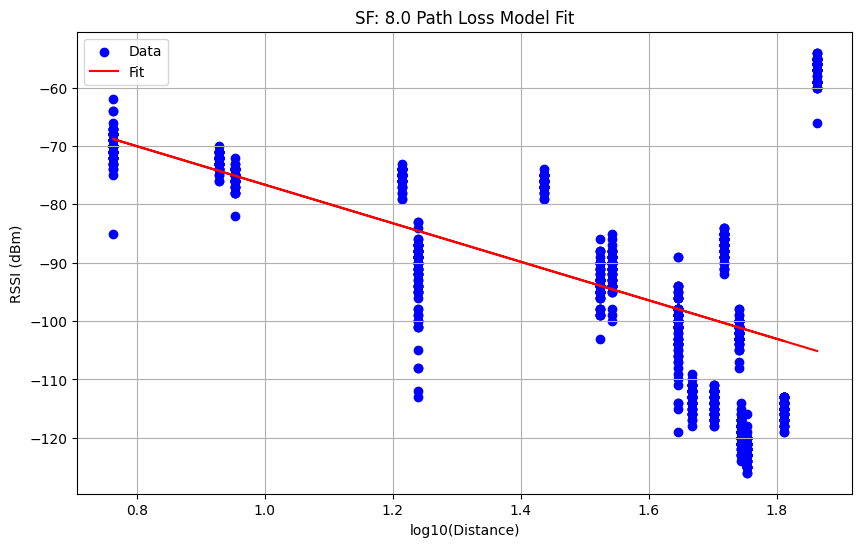

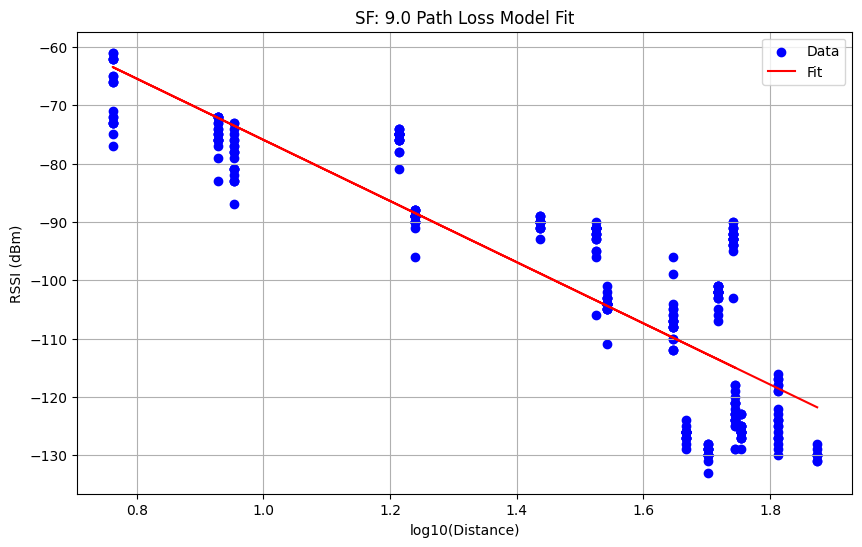

In [6]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

# 发射功率 (dBm)
p_tx = 2
save_path = r'model\v1\output\sf_parameters.csv'
# 定义路径损耗模型函数
def path_loss_model(log_d, gamma_sf, pl_0):
    return p_tx - pl_0 - 10 * gamma_sf * log_d

# 读取 RSSI 数据
# todo:同一个rssi的数据太多了，不妥
SF_RSSI_path = r'data\processedData\FLOOR3\all_data_new_fit.csv'
df_rssi = pd.read_csv(SF_RSSI_path)

# 读取距离数据 v3保存的是未归一化数据
location_vector_path = r'model\v1\output\location_vector_v3.csv'
df_distance = pd.read_csv(location_vector_path)

# 初始化结果存储
results = []

# 遍历每个 SF 值
for sf in df_rssi['sf'].unique():
    # 筛选当前 SF 的数据
    sf_data = df_rssi[df_rssi['sf'] == sf]
    
    # 获取对应的距离 (d) 和 RSSI 数据
    distances = []
    rssi_values = []
    for _, row in sf_data.iterrows():
        location_id = row['location_id']
        rssi = row['average_rssi']
        
        # 查找对应的距离 算sf的时候只用了vector-v3里的点，此处尽量都用上
        distance_row = df_distance[df_distance['location_id'] == location_id]
        if not distance_row.empty:
            distance = distance_row.iloc[0]['distance_true']
            distances.append(distance)
            rssi_values.append(rssi)
    
    # 转换为 numpy 数组
    distances = np.array(distances)
    rssi_values = np.array(rssi_values)
    
    # 过滤掉距离为 0 的数据，避免 log(0) 错误
    valid_indices = distances > 0    
    distances = distances[valid_indices]
    rssi_values = rssi_values[valid_indices]
    
    # 对距离取对数
    log_distances = np.log10(distances)
    
    # 使用最小二乘法拟合,并把拟合的曲线画出来
    try:
        popt, _ = curve_fit(path_loss_model, log_distances, rssi_values)
        gamma_sf, pl_0 = popt
        results.append({'sf': sf, 'gamma_sf': gamma_sf, 'pl_0': pl_0})
        print(f"SF: {sf}, γ_SF: {gamma_sf:.4f}, PL_0: {pl_0:.4f}")
        # 绘制拟合曲线
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 6))
        plt.scatter(log_distances, rssi_values, label='Data', color='blue')
        plt.plot(log_distances, path_loss_model(log_distances, *popt), label='Fit', color='red')
        plt.title(f'SF: {sf} Path Loss Model Fit')
        plt.xlabel('log10(Distance)')
        plt.ylabel('RSSI (dBm)')
        plt.legend()
        plt.grid()
        
        
    except Exception as e:
        print(f"SF: {sf} 拟合失败: {e}")

# 将结果保存为 DataFrame 并导出为 CSV
results_df = pd.DataFrame(results)
results_df.to_csv(save_path, index=False)
print("拟合结果已保存至 model\\v1\\output\\sf_parameters.csv")

